# Case Study 5: Internet Connection Request Classification
### Eric Graham
### DS 7333: Quantifying the World
### Dr. Robert Slater

## Introduction

The firewall log dataset contains 65,532 connection requests with four port columns and seven traffic volume features, labeled with one of four actions: allow, deny, drop, or reset-both. We encode the high cardinality port columns with a rare category bucket, then build a cross validated LinearSVC tuned for C and an SGDClassifier tuned for its L2 regularization strength, reporting confusion matrices and classification reports for all four classes. As a bonus, we reimplement the SGD model as a single layer network in PyTorch Lightning and compare results.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

## Data Loading

The data is a single CSV with no missing values. All columns are integers except the Action target.

In [2]:
data = pd.read_csv("./log2.csv")
print(data.shape)
data.head()

(65532, 12)


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,allow,177,94,83,2,30,1,1
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18


## EDA

The classes are heavily imbalanced. "reset-both" has only 54 examples, so it will be poorly-represented in every fold, thus we expect it to perform poorly.

In [3]:
data["Action"].value_counts()

Action
allow         37640
deny          14987
drop          12851
reset-both       54
Name: count, dtype: int64

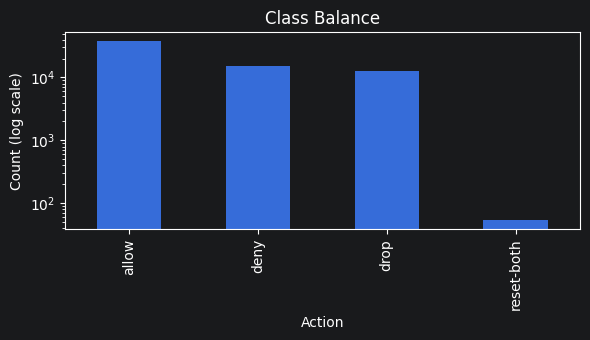

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
data["Action"].value_counts().plot.bar(ax=ax)
ax.set_yscale("log")
ax.set_ylabel("Count (log scale)")
ax.set_title("Class Balance")
plt.tight_layout()
plt.show()

The port columns are categorical despite being stored as integers, and their cardinality is enormous. One-hot encoding them directly would produce tens of thousands of columns, most representing ports seen only once.

In [5]:
port_cols = ["Source Port", "Destination Port", "NAT Source Port", "NAT Destination Port"]
data[port_cols].nunique()

Source Port             22724
Destination Port         3273
NAT Source Port         29152
NAT Destination Port     2533
dtype: int64

The traffic volume features are heavily right skewed, so since linear models are sensitive to feature scale, we standardize these before modeling.

In [6]:
numeric_cols = ["Bytes", "Bytes Sent", "Bytes Received", "Packets", "Elapsed Time (sec)", "pkts_sent", "pkts_received"]
data[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Bytes,65532.0,97123.950085,5.618439e+06,60.0,66.0,168.0,752.25,1.269359e+09
Bytes Sent,65532.0,22385.796908,3.828139e+06,60.0,66.0,90.0,210.00,9.484772e+08
Bytes Received,65532.0,74738.153177,2.463208e+06,0.0,0.0,79.0,449.00,3.208818e+08
Packets,65532.0,102.866035,5.133002e+03,1.0,1.0,2.0,6.00,1.036116e+06
Elapsed Time (sec),65532.0,65.833577,3.024618e+02,0.0,0.0,15.0,30.00,1.082400e+04
pkts_sent,65532.0,41.399530,3.218871e+03,1.0,1.0,1.0,3.00,7.475200e+05
pkts_received,65532.0,61.466505,2.223332e+03,0.0,0.0,1.0,2.00,3.272080e+05


## Encoding

With a 5 fold CV, any port value needs enough occurrences to land in multiple folds, so the guidelines suggest bucketing anything seen fewer than 5 to 15 times into a single rare category. We use 15, which cuts the one-hot width from about 4,250 columns to about 270 and gives the SVM a large speedup.

In [7]:
for col in port_cols:
    counts = data[col].value_counts()
    keep = counts[counts > 14].index
    data[col] = data[col].where(data[col].isin(keep), -1)

data[port_cols].nunique()

Source Port              83
Destination Port        141
NAT Source Port           5
NAT Destination Port     39
dtype: int64

We one hot encode the bucketed ports, standardize the numeric features, and combine everything into a single sparse matrix. Keeping the matrix sparse is the other half of the speedup, since LinearSVC handles sparse input natively.

In [8]:
encoder = OneHotEncoder()
port_features = encoder.fit_transform(data[port_cols])

scaler = StandardScaler()
numeric_features = scaler.fit_transform(data[numeric_cols])

X = sparse.hstack([port_features, sparse.csr_matrix(numeric_features)]).tocsr()
y = data["Action"]
X.shape

(65532, 275)

## LinearSVC

The lectures note that kernel SVMs hit their practical limit around 50,000 rows, which this dataset exceeds. We use LinearSVC instead, which combined with the rare port bucketing and the sparse matrix keeps each fit under a few seconds. We set "dual=False" since we have far more samples than features, and tune only C with a 5 fold grid search. The convergence warnings at large C are expected: weak regularization flattens the loss surface, so liblinear hits its default iteration cap before reaching tolerance, though those fits are already close to optimal.

In [9]:
svc_grid = GridSearchCV(LinearSVC(dual=False), param_grid={"C": np.logspace(-3, 3, 7)}, cv=5)
svc_grid.fit(X, y)
svc_grid.best_params_

/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converg

{'C': np.float64(1000.0)}

In [10]:
pd.DataFrame(svc_grid.cv_results_)[["param_C", "mean_test_score"]]

,param_C,mean_test_score
0,0.001,0.989776
1,0.010,0.995102
2,0.100,0.995758
3,1.000,0.995483
4,10.000,0.996277
5,100.000,0.996475
6,1000.000,0.996551


### Classification Report and Confusion Matrix

Regularization strength is inversely proportional to C, so the flat scores at large C mean the model wants little regularization. We refit at the best C with cross_val_predict so every prediction is out of fold and the support totals 65,532. The warnings repeat here because the best C sits in that weakly regularized range, with no meaningful effect on the predictions.

/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converg

              precision    recall  f1-score   support

       allow      0.999     0.997     0.998     37640
        deny      0.993     0.996     0.994     14987
        drop      0.997     1.000     0.998     12851
  reset-both      0.194     0.222     0.207        54

    accuracy                          0.997     65532
   macro avg      0.796     0.804     0.799     65532
weighted avg      0.997     0.997     0.997     65532



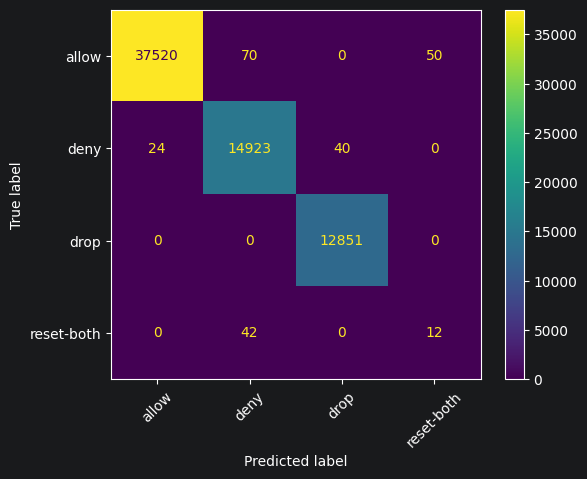

In [11]:
svc_preds = cross_val_predict(LinearSVC(C=svc_grid.best_params_["C"], dual=False), X, y, cv=5)
ConfusionMatrixDisplay.from_predictions(y, svc_preds, xticks_rotation=45)
print(classification_report(y, svc_preds, digits=3))

The model is near perfect on allow, deny, and drop, with 99.7% overall accuracy. reset-both manages an f1 of only about 0.2, since 54 examples split across 5 folds leaves roughly 43 training rows per fit, and most of its errors are confusions with deny.

## SGDClassifier

SGDClassifier fits the same family of linear models by stochastic gradient descent, updating on subsamples instead of solving over the full dataset at once. We choose the hinge loss, which makes this a linear SVM and a direct comparison to the LinearSVC above, and keep early stopping as in the guidelines so the number of epochs is not a fixed guess. We tune alpha, the L2 regularization strength, with a 5 fold grid search. Alpha is directly proportional to regularization strength, so small alpha means weak regularization.

In [12]:
sgd_grid = GridSearchCV(SGDClassifier(loss="hinge", early_stopping=True, random_state=42), param_grid={"alpha": np.logspace(-6, 6, 10)}, cv=5)
sgd_grid.fit(X, y)
sgd_grid.best_params_

{'alpha': np.float64(1e-06)}

In [13]:
pd.DataFrame(sgd_grid.cv_results_)[["param_alpha", "mean_test_score"]]

,param_alpha,mean_test_score
0,0.000001,0.995590
1,0.000022,0.995361
2,0.000464,0.994339
3,0.010000,0.989013
4,0.215443,0.989776
5,4.641589,0.994125
6,100.000000,0.797921
7,2154.434690,0.666456
8,46415.888336,0.666318
9,1000000.000000,0.666318


### Classification Report and Confusion Matrix

The best alpha lands at the weakly regularized end of the grid, consistent with the large C the SVM preferred, and accuracy collapses once alpha reaches 100 and regularization crushes the weights. As before, we generate out of fold predictions with cross_val_predict so the support totals 65,532. We pin random_state so the stochastic updates are reproducible, and sklearn warns that precision is undefined for any class the model never predicts, which foreshadows the result.

              precision    recall  f1-score   support

       allow      0.997     0.998     0.997     37640
        deny      0.991     0.991     0.991     14987
        drop      0.997     1.000     0.998     12851
  reset-both      0.000     0.000     0.000        54

    accuracy                          0.996     65532
   macro avg      0.746     0.747     0.747     65532
weighted avg      0.995     0.996     0.995     65532



/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

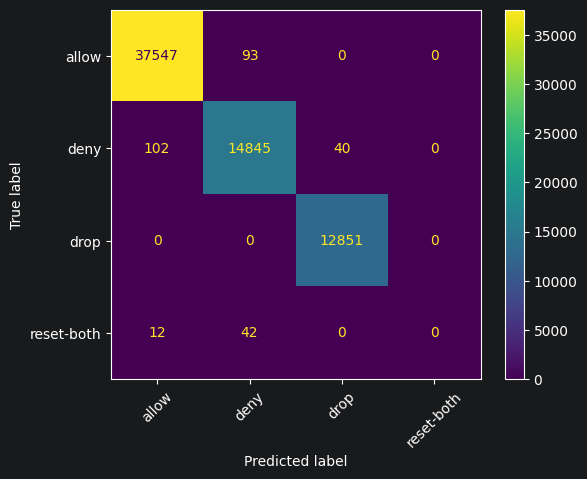

In [14]:
sgd_preds = cross_val_predict(SGDClassifier(loss="hinge", alpha=sgd_grid.best_params_["alpha"], early_stopping=True, random_state=42), X, y, cv=5)
ConfusionMatrixDisplay.from_predictions(y, sgd_preds, xticks_rotation=45)
print(classification_report(y, sgd_preds, digits=3))

SGD matches the LinearSVC almost exactly on allow, deny, and drop at 99.6% overall accuracy, but it never predicts reset-both, scoring an f1 of 0 where the LinearSVC recovered 12 of the 54. With so few examples, the noisy stochastic updates never build a stable boundary for the class, so the batch solver retains an edge on the rare category.

## Bonus: SGD in PyTorch Lightning

We reimplemented the SGD model as a single linear layer trained with PyTorch Lightning. The layer has 4 neurons because we have 4 classes and each neuron produces the logit for one class. 3 neurons would only suffice if we dropped reset-both. The assignment allows a train/test split for this bonus only, so we hold out a stratified 20% for evaluation.

In [15]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

The targets become integer codes and the sparse matrix becomes dense float32 tensors, which at 65,532 by 275 fits comfortably in memory. The DataLoader shuffles and serves mini batches, which is where the "stochastic" in SGD comes from here.

In [16]:
y_codes = y.astype("category").cat.codes.to_numpy()
class_names = y.astype("category").cat.categories.to_list()

X_train, X_test, y_train, y_test = train_test_split(X, y_codes, test_size=0.2, stratify=y_codes, random_state=42)

X_train_t = torch.tensor(X_train.toarray(), dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test.toarray(), dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=512, shuffle=True)

The Lightning module wraps one linear layer, cross entropy loss, and the SGD optimizer. Note where regularization is: nowhere. The optimizer's weight_decay defaults to 0, so unlike the sklearn models with their tuned C and alpha, this network trains completely unregularized unless we opt in.

In [17]:
class SGDNet(pl.LightningModule):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.layer = nn.Linear(n_features, n_classes)
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.layer(x)

    def training_step(self, batch, batch_idx):
        xb, yb = batch
        loss = self.loss_fn(self.layer(xb), yb)
        self.log("train_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), lr=0.1)

In [18]:
pl.seed_everything(42)
model = SGDNet(X_train_t.shape[1], 4)
trainer = pl.Trainer(max_epochs=20, accelerator="auto", devices=1, logger=False, enable_checkpointing=False, enable_progress_bar=False)
trainer.fit(model, train_loader)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layer   │ Linear           │  1.1 K │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 K                                                                                                
Total estimated model params size (MB): 0.004                                                                      
Modules in train mode: 2                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=20` reached.


### Confusion Matrix and Comparison

We score the held out 20% with the trained layer's argmax.

              precision    recall  f1-score   support

       allow      0.999     0.985     0.992      7528
        deny      0.960     0.996     0.978      2998
        drop      0.997     1.000     0.998      2570
  reset-both      0.000     0.000     0.000        11

    accuracy                          0.989     13107
   macro avg      0.739     0.745     0.742     13107
weighted avg      0.989     0.989     0.989     13107



/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/data/school/ds_7333_quantifying_the_world/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

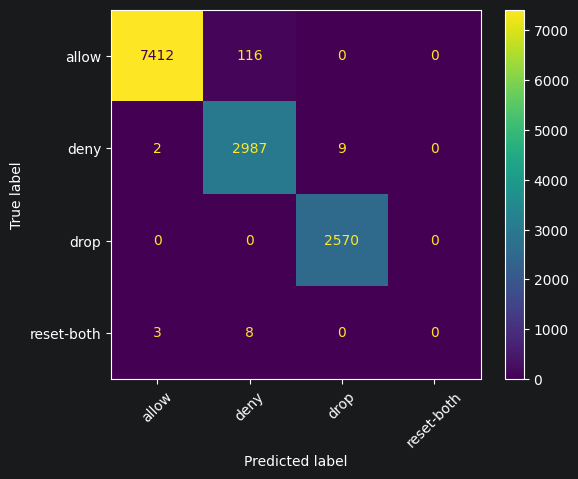

In [19]:
model = model.cpu()
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t).argmax(dim=1).numpy()

ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=class_names, xticks_rotation=45)
print(classification_report(y_test, test_preds, target_names=class_names, digits=3))

The network reaches 98.9% test accuracy against the sklearn SGDClassifier's 99.6%, and the differences trace to specific implementation choices. This model runs a fixed 20 epochs of mini batch updates where sklearn used early stopping, carries no regularization where sklearn tuned alpha, and is scored on a single 20% holdout where sklearn was scored out of fold over all 65,532 rows. The rare class behaves the same way for the same reason: the model never predicts reset-both, so its 11 test examples score 0 recall, and sklearn warns that precision is undefined for a class with no predicted samples.

## Conclusion

Both required models classify firewall actions almost perfectly, with the LinearSVC at 99.7% accuracy and the SGDClassifier at 99.6%, and both were tuned with cross validation only so every reported number is out of fold over all 65,532 rows. The rare port bucketing was the key feature-engineering step, trimming the one-hot width considerably and making the SVM workable, and the batch LinearSVC proved slightly better than SGD at reset-both (whose 54 examples are simply too few for any of the three implementations, including the PyTorch bonus, to classify reliably). In production, we would treat reset-both as a candidate for anomaly detection or collect more examples rather than expect a 4 class linear model to catch it.